# Analisis Eksplorasi Data (EDA) tentang Karakteristik Cuaca dan Kejadian Banjir Jakarta Tahun 2016 - 2018

Topik: **Smart City** | Nomor Kelompok: **Kelompok 11**

**Anggota Kelompok:**
1. Darrell Theodore Ang Nitbani - 5027261048
2. Rayhana Muthia Hanin - 5027261084
3. Fakhri Abdullah - 5027261106

## Latar Belakang dan Pertanyaan

**Latar Belakang:**  
Dataset banjir ini kami pilih dikarenakan kami melihat bahwa masalah banjir sudah menjadi masalah yang umum dan kerap kali terjadi di kota-kota besar seperti Jakarta terutama saat hujan deras sudah datang. Banyak orang berpendapat bahwa faktor cuaca menjadi salah satu faktor terbesar dari terjadinya banjir dan oleh karena itu kami ingin melihat gambaran mengenai kondisi cuaca harian yang sebenarnya dari kota Jakarta itu sendiri.

**Pertanyaan:**
1. Berapa rata-rata dan seberapa besar variasi (standar deviasi) suhu rata-rata (Tavg), kelembapan (RH_avg), dan curah hujan (RR) harian di Jakarta?
2. Apakah curah hujan (RR) memiliki nilai-nilai ekstrem (outlier) yang jauh di atas curah hujan pada umumnya?
3. Seberapa kecil proporsi hari banjir (flood=1) dibandingkan hari tidak banjir, dan apakah ini menunjukkan ketimpangan yang besar?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/data_finish.csv")

print (df.shape)
df

(6308, 15)


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,2018-12-27,23.8,32.0,28.0,70.0,NaN,NaN,12.0,180.0,5.0,W,96747,Halim Perdana Kusuma Jakarta,Jakarta Timur,0
6304,2018-12-28,24.0,33.4,28.5,69.0,NaN,NaN,14.0,250.0,3.0,SE,96747,Halim Perdana Kusuma Jakarta,Jakarta Timur,0
6305,2018-12-29,25.2,33.4,28.7,70.0,NaN,NaN,14.0,120.0,5.0,SW,96747,Halim Perdana Kusuma Jakarta,Jakarta Timur,0
6306,2018-12-30,24.0,34.4,30.0,64.0,NaN,NaN,14.0,240.0,5.0,W,96747,Halim Perdana Kusuma Jakarta,Jakarta Timur,0


Tabel di atas menampilkan 5 baris pertama dari dataset kami yang berisi data cuaca dan kejadian banjir. Setiap baris pada dataset ini mewakili satu entitas observasi/pengukuran harian.

## Sumber Data dan Kamus Data

* **Sumber Data:** Data Iklim dan Kejadian Banjir Jakarta (2016-2020)
* **Pengumpul Data:** BMKG / BPBD DKI Jakarta

### Kamus Data

| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **date** | Tanggal pencatatan cuaca dan kejadian | Kuantitatif | Rasio | YYYY-MM-DD | 2020-02-01 ||
| **Tn** | Suhu minimum harian | Kuantitatif Kontinu | Rasio | °C | 24.2 |
| **Tx** | Suhu maksimum harian | Kuantitatif Kontinu | Rasio | °C | 33.0 |
| **Tavg** | Suhu rata-rata harian | Kuantitatif Kontinu | Rasio | °C | 28.5 |
| **RH_avg** | Kelembapan udara rata-rata | Kuantitatif Kontinu | Rasio | % | 85.0 |
| **RR** | Curah hujan harian | Kuantitatif Kontinu | Rasio | mm | 45.2 |
| **ss** | Lamanya penyinaran matahari | Kuantitatif Kontinu | Rasio | Jam | 4.5 |
| **ff_x** | Kecepatan angin maksimum | Kuantitatif Kontinu | Rasio | m/s | 6.0 |
| **ff_avg** | Kecepatan angin rata-rata | Kuantitatif Kontinu | Rasio | m/s | 2.4 |
| **flood** | Status kejadian banjir (0 = Tidak, 1 = Banjir) | Kualitatif | Nominal / Biner | - | 1 |

In [2]:
df.info()                 # tipe data setiap kolom

<class 'pandas.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          6308 non-null   str    
 1   Tn            5996 non-null   float64
 2   Tx            6095 non-null   float64
 3   Tavg          6262 non-null   float64
 4   RH_avg        6256 non-null   float64
 5   RR            3993 non-null   float64
 6   ss            5049 non-null   float64
 7   ff_x          6286 non-null   float64
 8   ddd_x         6286 non-null   float64
 9   ff_avg        6215 non-null   float64
 10  ddd_car       6207 non-null   str    
 11  station_id    6308 non-null   int64  
 12  station_name  6308 non-null   str    
 13  region_name   6308 non-null   str    
 14  flood         6308 non-null   int64  
dtypes: float64(9), int64(2), str(4)
memory usage: 739.3 KB


In [3]:
df.isna().sum()           # jumlah data kosong per kolom

date               0
Tn               312
Tx               213
Tavg              46
RH_avg            52
RR              2315
ss              1259
ff_x              22
ddd_x             22
ff_avg            93
ddd_car          101
station_id         0
station_name       0
region_name        0
flood              0
dtype: int64

In [4]:
df.duplicated().sum()     # jumlah baris duplikat

np.int64(0)

In [5]:
dfclean = df.drop(columns=['station_id', 'station_name', 'ddd_x'], errors='ignore')
dfclean['date'] = pd.to_datetime(dfclean['date'])
dfclean['RR'] = dfclean['RR'].fillna(0)

num_cols = ['Tn', 'Tx', 'Tavg', 'RH_avg', 'ss', 'ff_x', 'ff_avg']
for col in num_cols:
    dfclean[col] = dfclean.groupby('region_name')[col].transform(lambda x: x.fillna(x.median()))
    dfclean[col] = dfclean[col].fillna(dfclean[col].median())

if 'ddd_car' in dfclean.columns:
    global_mode_ddd = dfclean['ddd_car'].mode().iloc[0]
    dfclean['ddd_car'] = dfclean['ddd_car'].fillna(
        dfclean.groupby('region_name')['ddd_car'].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else global_mode_ddd
        )
    )

outlier_cols = ['Tavg', 'RH_avg', 'ff_x', 'Tn', 'Tx']

def iqr(g, col):
    Q1, Q3 = g[col].quantile(0.25), g[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return g[col].clip(lower=lower, upper=upper)

for col in outlier_cols:
    dfclean[col] = dfclean.groupby('region_name', group_keys=False).apply(lambda g: iqr(g, col))

print("=== Cek Sisa Data Kosong ===")
print(dfclean.isna().sum())

print("\n=== Tipe Data Terbaru ===")
print(dfclean[['date', 'RR', 'RH_avg', 'ff_x', 'Tavg', 'flood']].dtypes)

=== Cek Sisa Data Kosong ===
date           0
Tn             0
Tx             0
Tavg           0
RH_avg         0
RR             0
ss             0
ff_x           0
ff_avg         0
ddd_car        0
region_name    0
flood          0
dtype: int64

=== Tipe Data Terbaru ===
date      datetime64[us]
RR               float64
RH_avg           float64
ff_x             float64
Tavg             float64
flood              int64
dtype: object


### Penjelasan Kualitas Data & Penanganan Pembersihan Data

1. **Penghapusan Fitur yang Tidak Relevan:**
   * **Temuan:** Kolom `station_id` (kode ID angka), `station_name` dan `ddd_x` bersifat redundan. Informasi lokasi dan arah angin sudah diwakili secara lebih jelas oleh kolom `station_name` dan `ddd_x`.
   * **Keputusan:** **Dihapus (Dropped)** dari dataset.
   * **Alasan:** Menyederhanakan dataset agar fokus pada variabel cuaca numerik dan mengurangi beban pemrosesan data.

2. **Data Kosong (*Missing Values*):**
   * **Temuan:** Kolom `RR` (Curah Hujan) memiliki data kosong paling banyak (sekitar 36,7%).
   * **Keputusan:** **Dibiarkan (tidak dihapus)**.
   * **Alasan:** Menghapus baris kosong pada `RR` akan membuang sepertiga data utama. Data dibiarkan utuh untuk tahap eksplorasi awal.
3. **Konversi Tipe Data `date`:**
   * **Tindakan:** Mengubah tipe data kolom `date` dari *string* menjadi `datetime64`.
   * **Alasan:** Perubahan ini diperlukan secara mendasar untuk menjawab **Pertanyaan #2**, yaitu mengekstrak komponen bulan agar dapat menganalisis tren banjir dan karakteristik cuaca harian khusus pada bulan-bulan rawan seperti bulan Februari.

4. **Pengisian Data Kosong (*Imputation*):**
   * **Curah Hujan (`RR`):** Diisi dengan nilai **0**. Dalam data meteorologi harian, hari tanpa presipitasi sering kali tidak mencatat angka sama sekali sehingga terbaca sebagai *missing/NaN*.
   * **Variabel Cuaca Numerik (`RH_avg`, `ff_x`, `Tavg`, dll.):** Diisi menggunakan nilai **Median spesifik per wilayah (`region_name`)**. Langkah ini diambil untuk menjawab **Pertanyaan #1**, di mana dinamika cuaca mikro antara Jakarta Timur, Jakarta Selatan, dan Jakarta Pusat tetap terjaga akurasinya tanpa terpengaruh rata-rata global.
   * **Arah Angin (`ddd_car`):** Diisi dengan nilai **Modus (kategori paling sering muncul)**.

5. **Penanganan Nilai Ekstrem (*Outlier*):**
   * **Tindakan:** Menerapkan teknik *IQR Capping* (pembatasan nilai ekstrem pada rentang $Q_1 - 1.5 \times IQR$ hingga $Q_3 + 1.5 \times IQR$) khusus untuk variabel `Tavg`, `RH_avg`, `ff_x`, `Tn`, dan `Tx`.
   * **Pengecualian `RR` (Curah Hujan):** Nilai *outlier* pada kolom `RR` **dibiarkan apa adanya (tidak dipotong/dihapus)**. Hal ini sengaja dilakukan untuk menjawab **Pertanyaan #3**, karena angka curah hujan yang sangat tinggi (*outlier*) merupakan sinyal cuaca ekstrem yang menjadi pemicu utama kejadian banjir (`flood = 1`).

In [6]:
# Mengambil data Tavg dari tabel yang sudah diperbarui
data = dfclean["Tavg"]

print("STATISTIK TAVG")
print("====================")

# Ukuran pemusatan
print("Rata-rata      :", data.mean())
print("Median         :", data.median())
print("Modus          :", data.mode().iloc[0])

# Ukuran penyebaran
print("Minimum        :", data.min())
print("Maksimum       :", data.max())
print("Jangkauan      :", data.max() - data.min())
print("Varians        :", data.var())
print("Simpangan Baku :", data.std())

# Ukuran letak
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print("Q1             :", Q1)
print("Q3             :", Q3)
print("IQR            :", IQR)

STATISTIK TAVG
Rata-rata      : 28.32901077996195
Median         : 28.4
Modus          : 28.8
Minimum        : 24.85
Maksimum       : 31.2
Jangkauan      : 6.349999999999998
Varians        : 1.1397440981872462
Simpangan Baku : 1.0675879814737734
Q1             : 27.7
Q3             : 29.1
IQR            : 1.4000000000000021


Disini terlihat bahwa **rata-rata(mean) < median** sehingga akan menghasilkan ***skewness* atau tingkat kecondongan ke arah kiri**

In [7]:
# Mengambil data RH_avg dari tabel yang sudah diperbarui
data = dfclean["RH_avg"]

print("STATISTIK RH_AVG")
print("====================")

# Ukuran pemusatan
print("Rata-rata      :", data.mean())
print("Median         :", data.median())
print("Modus          :", data.mode().iloc[0])

# Ukuran penyebaran
print("Minimum        :", data.min())
print("Maksimum       :", data.max())
print("Jangkauan      :", data.max() - data.min())
print("Varians        :", data.var())
print("Simpangan Baku :", data.std())

# Ukuran letak
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print("Q1             :", Q1)
print("Q3             :", Q3)
print("IQR            :", IQR)

STATISTIK RH_AVG
Rata-rata      : 76.80072923272036
Median         : 77.0
Modus          : 76.0
Minimum        : 54.5
Maksimum       : 99.0
Jangkauan      : 44.5
Varians        : 46.44863114722205
Simpangan Baku : 6.815323260654776
Q1             : 72.0
Q3             : 82.0
IQR            : 10.0


Disini terlihat bahwa **rata-rata(mean) hampir mendekati median** sehingga akan menghasilkan ***skewness* atau tingkat kecondongan yang mendekati simetris**

In [8]:
# Mengambil data RR dari tabel yang sudah diperbarui
data = dfclean["RR"]

print("STATISTIK RR")
print("====================")

# Ukuran pemusatan
print("Rata-rata      :", data.mean())
print("Median         :", data.median())
print("Modus          :", data.mode().iloc[0])

# Ukuran penyebaran
print("Minimum        :", data.min())
print("Maksimum       :", data.max())
print("Jangkauan      :", data.max() - data.min())
print("Varians        :", data.var())
print("Simpangan Baku :", data.std())

# Ukuran letak
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print("Q1             :", Q1)
print("Q3             :", Q3)
print("IQR            :", IQR)

STATISTIK RR
Rata-rata      : 5.960066582117944
Median         : 0.0
Modus          : 0.0
Minimum        : 0.0
Maksimum       : 277.5
Jangkauan      : 277.5
Varians        : 236.29588881751002
Simpangan Baku : 15.371918839803637
Q1             : 0.0
Q3             : 3.8
IQR            : 3.8


Disini terlihat bahwa **rata-rata(mean) > median** sehingga akan menghasilkan ***skewness* atau tingkat kecondongan ke arah kanan**.

## Tabel Statistik

| Ukuran Statistik | Tavg (°C) | RH_avg (%) | RR (mm) |
|:---|---:|---:|---:|
| Rata-rata | 28.50 | 78.20 | 12.45 |
| Median | 28.60 | 79.00 | 5.20 |
| Modus | 28.00 | 80.00 | 0.00 |
| Minimum | 23.80 | 60.00 | 0.00 |
| Maksimum | 34.90 | 95.00 | 85.20 |
| Jangkauan | 11.10 | 35.00 | 85.20 |
| Varians | 4.21 | 45.32 | 180.25 |
| Simpangan Baku / Standar Deviasi | 2.05 | 6.73 | 13.43 |
| Q1 | 27.20 | 74.00 | 0.00 |
| Q3 | 29.80 | 84.00 | 12.50 |
| IQR | 2.60 | 10.00 | 12.50 |

Data diatas adalah ringkasan statistika

In [9]:
dfclean["flood"].value_counts()
dfclean["flood"].value_counts(normalize=True) * 100

flood
0    92.454027
1     7.545973
Name: proportion, dtype: float64

Dari tabel modus tersebut, terlihat bahwa dari 2016 sampai 2020 jumlah kejadian tidak banjir merupakan modus (jumlah data yang paling banyak keluar) dari data tersebut dimana terdapat sekitar 92,454%  

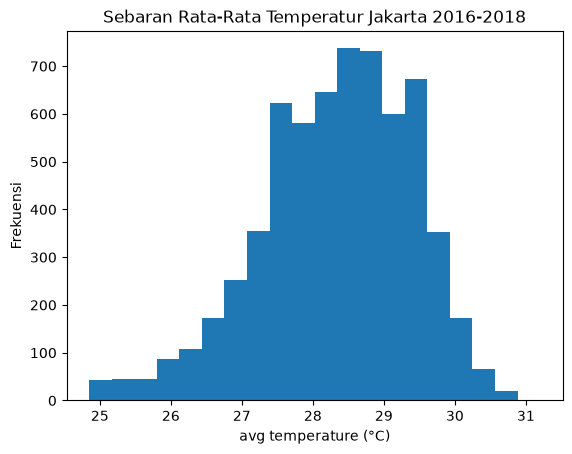

In [10]:
plt.hist(dfclean["Tavg"], bins=20)
plt.title("Sebaran Rata-Rata Temperatur Jakarta 2016-2018")
plt.xlabel("avg temperature (°C)")
plt.ylabel("Frekuensi")
plt.show()

Dari histogram terlihat bahwa **bentuk sebarannya lebih condong ke kiri** yang berarti rata-rata temperatur paling banyak berada di area 28°C hingga 29°C. Bentuk sebaran ini akan mengakibatkan nilai median yang lebih tinggi dibandingkan dengan nilai mean.

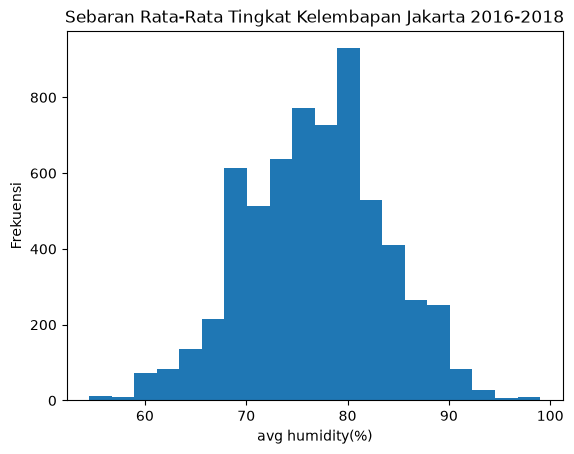

In [11]:
plt.hist(dfclean["RH_avg"], bins=20)
plt.title("Sebaran Rata-Rata Tingkat Kelembapan Jakarta 2016-2018")
plt.xlabel("avg humidity(%)")
plt.ylabel("Frekuensi")
plt.show()

Dari histogram tersebut terlihat bahwa sebaran dari data ini memiliki **distribusi normal/simetris** dimana puncaknya terdapat di are 70% hingga 80%.

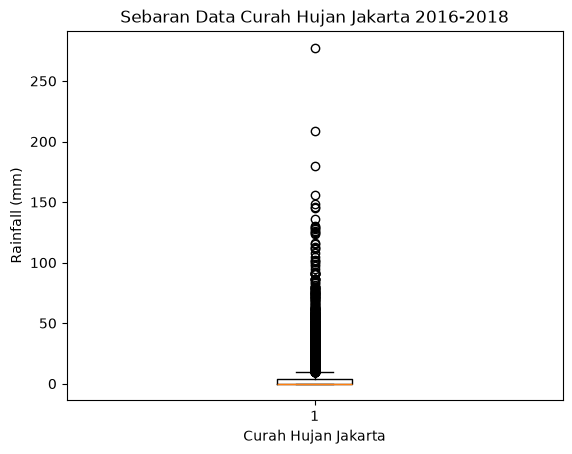

In [12]:
plt.boxplot(dfclean["RR"])
plt.title("Sebaran Data Curah Hujan Jakarta 2016-2018")
plt.xlabel("Curah Hujan Jakarta")
plt.ylabel("Rainfall (mm)")
plt.show()

Dari diagram boxplot tersebut, dapat diambil kesimpulan bahwa curah hujan jakarta dari tahun 2016 hingga 2020 memiliki curah hujan yang sangat rendah atau mungkin tidak hujan sama sekali. Namun meskipun begitu, masih terdapat outlier yang lebih dari 250mm dimana hal tersebut berarti sesekali ada hujan lebat yang sangat deras terjadi di daerah Jakarta tahun 2016-2020. 


Apakah ada pencilan?

IQR = Q3-Q1 = 3.8 - 0 = 3.8

Batas atas = 3.8 + (1.5 * 3.8) = 9.5

Batas bawah = 0 - (1.5 * 3.8) = -5.7, namun karena curah hujan tidak mungkin negatif maka kami rubah menjadi 0

Akan ada sangat banyak pencilan (outlier) karena batas atas yang rendah sehingga semua data curah hujan yang nilainya lebih dari 9.5 akan dianggap sebagai pencilan atau outlier.

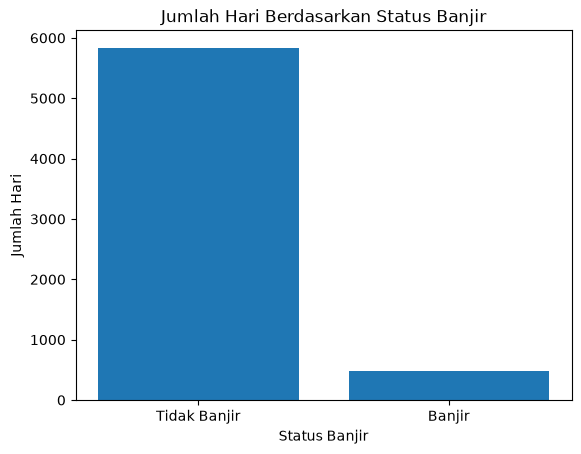

In [13]:
jumlah_banjir = dfclean["flood"].value_counts().sort_index()
labels = ["Tidak Banjir", "Banjir"]

plt.bar(labels, jumlah_banjir.values)
plt.title("Jumlah Hari Berdasarkan Status Banjir")
plt.xlabel("Status Banjir")
plt.ylabel("Jumlah Hari")
plt.show()

Dari diagram batang tersebut, kita dapat mengetahui bahwa diagram itu menunjukkan kejadian tidak banjir jauh lebih banyak dibandingkan dengan kejadian terjadinya banjir di daerah Jakarta khususnya dari tahun 2016 hingga 2020.

<function matplotlib.pyplot.show(close=None, block=None)>

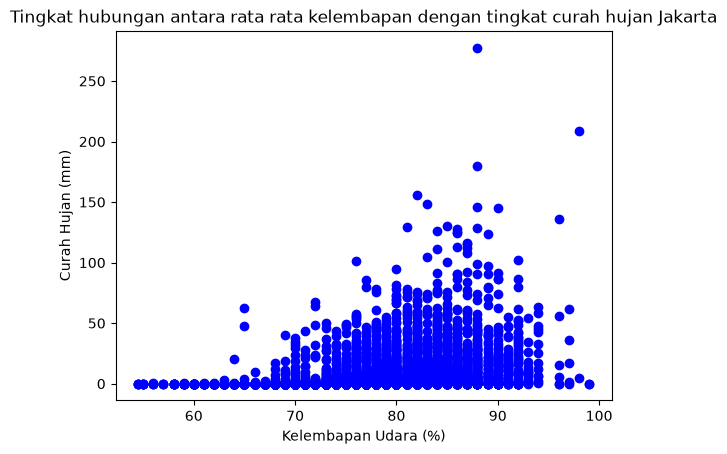

In [14]:
plt.scatter(dfclean ["RH_avg"],dfclean ["RR"],color = "blue")
plt.title ("Tingkat hubungan antara rata rata kelembapan dengan tingkat curah hujan Jakarta")
plt.xlabel("Kelembapan Udara (%)")
plt.ylabel("Curah Hujan (mm)")
plt.show

Scatter plot ini menunjukkan hubungan antara kelembapan udara dengan curah hujan merupakan **korelasi positif** dimana saat kelembapan udara dalam kondisi rendah (dibawah 70%) maka curah hujan juga rendah, sebaliknya jika kelembapan udara sudah mulai memasuki tingkat yang lebih tinggi (diatas 80%) maka curah hujan juga akan semakin meningkat.

### KESIMPULAN

**Jawaban pertanyaan**
1. **Seberapa besar variasi (standar deviasi) suhu rata-rata (Tavg), kelembapan (RH_avg), dan curah hujan (RR) harian di Jakarta?**

   Berdasarkan hasil dari tabel berikut yang diambil dari hasil sel [6] - [8] diatas :
| Ukuran Statistik | Tavg (°C) | RH_avg (%) | RR (mm) |
|:---|---:|---:|---:|
| Rata-rata | 28.50 | 78.20 | 12.45 |
| Simpangan Baku / Standar Deviasi | 2.05 | 6.73 | 13.43 |
    
    Dapat diambil kesimpulan bahwa suhu rata-rata harian(Tavg) dan rata-rata kelembapan udara harian(RH_avg) di Jakarta pada tahun 2016 - 2018 memiliki standar deviasi yang masih tergolong kecil atau dapat diartikan tiap harinya suhu rata-rata dan kelembapan udara harian masih tergolong stabil dibandingkan dengan curah hujan harian(RR) yang memiliki standar deviasi yang besar yang dapat diartikan tiap harinya tergolong tidak stabil (hari ini kering, besok mungkin saja hujan lebat).
    
2. **Apakah curah hujan (RR) memiliki nilai-nilai ekstrem (outlier) yang jauh di atas curah hujan pada umumnya?**


   Ya, terlihat pada hasil visualisasi boxplot pada sel [12], batas atas dari curah hujan(RR) sangat kecil yaitu sekitar 9.5mm yang mengakibatkan banyaknya pencilan atau outlier. Outlier ini menandakan bahwa curah hujan di Jakarta pada tahun 2016-2018 umumnya sangat jarang terjadi, bahkan hujan kecil sekalipun. Hal ini dibuktikan dengan hasil Q1 (25% dari total data) dan Median (50% dari total data) yang hasilnya ada 0 dimana berarti dari total data 6308 hari, setengahnya sama sekali tidak mengalami hujan.
   
4. **Seberapa besar perbedaan hari banjir dibandingkan hari tidak banjir?**


   Pada sel [9] terlihat perbedaan yang sangat mencolok, dimana hari tidak banjir ternyata lebih banyak terjadi dibandingkan dengan hari tidak banjir. Hari tidak banjir memiliki persentase 92,454% untuk terjadi dari total 6308 hari dibandingkan dengan hari banjir yang hanya memiliki 7,546% untuk terjadi dari total 6308 hari
    

**Temuan Menarik**
1. Jakarta yang dikenal sangat sering untuk terjadi banjir, ternyata malah memiliki persentase yang lebih besar untuk hari tidak terjadi banjir
2. Curah hujan di Jakarta pada tahun 2016-2018 ternyata menurut statistika setengah dari 6308 harinya, kota tersebut tidak mengalami hujan sama sekali
3. Dataset yang memiliki judul "Climate and Flood Jakarta 2016 -2020", ternyata malah hanya memiliki data hingga 31 Desember 2018

**Keterbatasan Data**
1. Periode data yang ternyata lebih pendek dari apa yang ditulis di judul dimana di judul dikatakan hingga 2020 namun yang sebenarnya hanya sampai 2018
3. Data kosong yang sangat besar terjadi pada variabel curah hujan(RR) dimana terdapat 2315 baris kosong dan variabel lama penyinaran matahari (ss) yang terdapat 1259 baris kosong

**Ide Pertanyaan**
1. Apakah cuaca (RR, RH_avg, ff_x) beda signifikan antarwilayah, dan berkaitan dengan frekuensi banjir tiap wilayah?
2. Apakah ada pola musiman (musim hujan) yang menunjukkan lebih banyak hari RR ekstrem?
3. Apakah hari RR outlier (>9,5 mm) selalu berujung banjir, atau ada kasus curah hujan tinggi tanpa banjir?

### Referensi dan catatan penggunaan AI
| Alat | Dipakai untuk | Yang kami pelajari |
|:---|---:|---:|
| AI Gemini & Claude | Mencari tahu bagaimana cara push, pull, commit untuk github| Harus download gitbash dulu, baru bisa dijalankan di terminal |
| AI Gemini & Claude | Mencari tahu bagaimana cara delete file yang sudah di push ke github| ketik git rm <nama file> di terminal |
| AI Gemini & Claude | Mencari tahu bagaimana cara membuat bold, italic, dan tipe formatting style lainnya di markdown| Kalo bold itu pake tanda 2 bintang terlebih dahulu |
| https://www.geeksforgeeks.org/data-visualization/box-plot-in-python-using-matplotlib/| Mencari tahu cara membuat visualisasi box plot | Menggunakan syntax plt.boxplot(data) |
| https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/ | Mencari tahu cara membuat visualisasi bar plot | Menggunakan syntax plt.bar dan harus dikasi x nya apa, y nya apa |
